# Satellite Land Cover Classification
## 03 - KNN Model Training and Evaluation

In [1]:
from pathlib import Path

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

,Mean_R,Mean_G,Mean_B,Std_R,Std_G,Std_B,Label,Brightness
0,44.347412,64.375488,80.707031,3.513459,3.138506,2.012561,Forest,63.143311
1,46.671143,73.987549,83.954102,6.793193,5.550029,4.262200,Forest,68.204264
2,32.073975,55.816162,67.113281,4.821334,5.024223,2.951324,Forest,51.667806
3,41.936279,65.127930,81.393555,1.940922,1.913598,1.871846,Forest,62.819255
4,39.153076,63.942383,77.635010,2.308962,2.951115,1.872090,Forest,60.243490


In [3]:
# Features: everything except the label
X = df.drop("Label", axis=1)

# Labels: what we want to predict
y = df["Label"]

print("Features:")
print(X.head())

print("\nLabels:")
print(y.head())

Features:
      Mean_R     Mean_G     Mean_B     Std_R     Std_G     Std_B  Brightness
0  44.347412  64.375488  80.707031  3.513459  3.138506  2.012561   63.143311
1  46.671143  73.987549  83.954102  6.793193  5.550029  4.262200   68.204264
2  32.073975  55.816162  67.113281  4.821334  5.024223  2.951324   51.667806
3  41.936279  65.127930  81.393555  1.940922  1.913598  1.871846   62.819255
4  39.153076  63.942383  77.635010  2.308962  2.951115  1.872090   60.243490

Labels:
0    Forest
1    Forest
2    Forest
3    Forest
4    Forest
Name: Label, dtype: str


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 6800
Testing samples: 1700


In [5]:
# Create the KNN classifier
knn_model = KNeighborsClassifier(n_neighbors=5)

print(knn_model)

KNeighborsClassifier()


In [6]:
# Train the model
knn_model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [7]:
# Use the trained model to predict the test set
y_pred = knn_model.predict(X_test)

# Show the first 10 predictions
y_pred[:10]

array(['Residential', 'Residential', 'Residential', 'Residential',
       'Residential', 'Forest', 'Forest', 'River', 'Forest', 'River'],
      dtype=object)

In [8]:
# Calculate how many predictions were correct
accuracy = accuracy_score(y_test, y_pred)

print(f"Model accuracy: {accuracy:.2%}")

Model accuracy: 96.76%


In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Forest       0.99      1.00      0.99       628
 Residential       0.94      0.98      0.96       609
       River       0.97      0.91      0.94       463

    accuracy                           0.97      1700
   macro avg       0.97      0.96      0.96      1700
weighted avg       0.97      0.97      0.97      1700



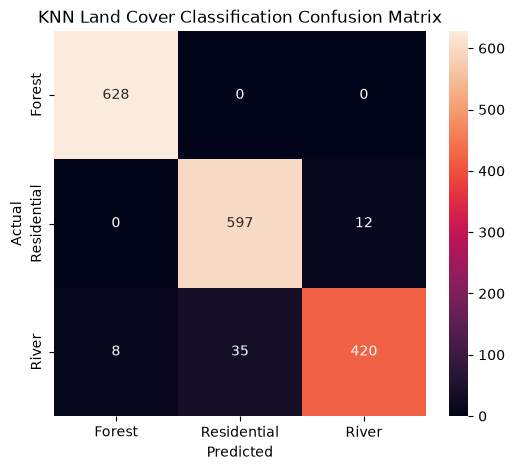

In [11]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=knn_model.classes_,
    yticklabels=knn_model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Land Cover Classification Confusion Matrix")

plt.show()

In [12]:
import pickle

In [13]:
# Create a folder for saved models
model_path = Path("../models")

model_path.mkdir(exist_ok=True)

# Save the trained model
with open(model_path / "knn_landcover_model.pkl", "wb") as file:
    pickle.dump(knn_model, file)

print("Model saved successfully!")

Model saved successfully!


In [14]:
import random

# Pick a random image from the Forest folder
forest_images = list(Path("../data/raw/eurosat_subset/Forest").glob("*.jpg"))

random_image = random.choice(forest_images)

print(random_image)

../data/raw/eurosat_subset/Forest/Forest_1362.jpg


In [17]:
from PIL import Image
import numpy as np

In [18]:
# Open the image
image = Image.open(random_image)

# Convert to NumPy array
image_array = np.array(image)

# Extract features
features = {
    "Mean_R": image_array[:, :, 0].mean(),
    "Mean_G": image_array[:, :, 1].mean(),
    "Mean_B": image_array[:, :, 2].mean(),
    "Std_R": image_array[:, :, 0].std(),
    "Std_G": image_array[:, :, 1].std(),
    "Std_B": image_array[:, :, 2].std(),
}

# Add brightness
features["Brightness"] = (
    features["Mean_R"] +
    features["Mean_G"] +
    features["Mean_B"]
) / 3

features

{'Mean_R': np.float64(38.536376953125),
 'Mean_G': np.float64(60.343017578125),
 'Mean_B': np.float64(73.344482421875),
 'Std_R': np.float64(6.660330685655281),
 'Std_G': np.float64(4.835655037760889),
 'Std_B': np.float64(3.3140081804959585),
 'Brightness': np.float64(57.407958984375)}

In [20]:
# Convert features into a DataFrame
new_image_features = pd.DataFrame([features])

new_image_features

,Mean_R,Mean_G,Mean_B,Std_R,Std_G,Std_B,Brightness
0,38.536377,60.343018,73.344482,6.660331,4.835655,3.314008,57.407959


In [21]:
prediction = knn_model.predict(new_image_features)

print("Model prediction:", prediction[0])

Model prediction: Forest


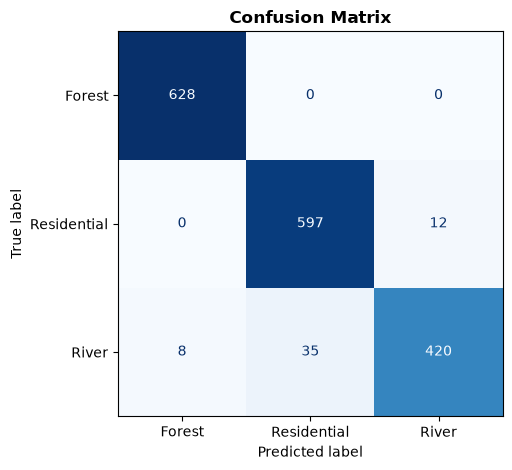

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    colorbar=False
)

plt.title("Confusion Matrix",
          fontweight="bold")

plt.tight_layout()

plt.savefig("../images/confusion_matrix.png",
            dpi=300)

plt.show()

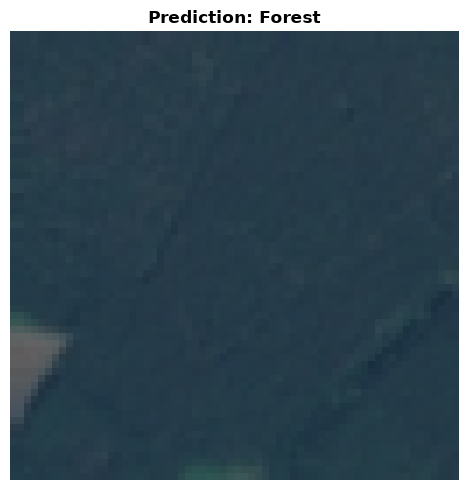

In [23]:
plt.figure(figsize=(5,5))

plt.imshow(image)

plt.title(
    f"Prediction: {prediction[0]}",
    fontweight="bold"
)

plt.axis("off")

plt.tight_layout()

plt.savefig("../images/prediction_example.png",
            dpi=300)

plt.show()